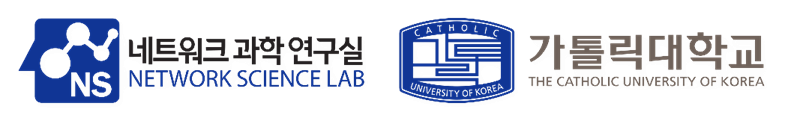


# Practice Code 3: The Expressive Power of Graph Neural Networks


### Overview

1. What "expressive" means
2. A concrete failure: $C_6$ vs $2\times C_3$
3. Computational graphs (unfolding trees)
4. Color refinement (1-WL)
5. GIN
6. Where 1-WL fails
7. $k$-WL and $k$-GNNs
8. GSN, GNN-AK, ESAN


## 1. Setup


In [1]:
import warnings
warnings.filterwarnings("ignore")

from collections import Counter

import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgba

plt.rcParams.update({
    "figure.dpi": 110,
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
})

C_TARGET, C_EDGE, C_DARK, C_PLAIN = "#E74C3C", "#95A5A6", "#2C3E50", "#D5D8DC"
C_RED, C_BLUE, C_GREEN = "#E74C3C", "#3498DB", "#27AE60"

# Color id -> RGBA. Ids 1-9 are pastel hues, 10-18 darker ones, then the cycle repeats.
# Id 0 means "no color" (plain gray), so the grays of tab20 (14, 15) are left out.
_TAB20 = plt.get_cmap("tab20")
_ORDER = [i for i in range(1, 20, 2) if i != 15] + [i for i in range(0, 20, 2) if i != 14]


def color_of(cid):
    return to_rgba(C_PLAIN) if cid == 0 else _TAB20(_ORDER[(int(cid) - 1) % len(_ORDER)])


def ink(rgba):
    """Readable text color on top of `rgba`."""
    r, g, b = rgba[:3]
    return "white" if 0.299 * r + 0.587 * g + 0.114 * b < 0.5 else C_DARK


def draw_graph(G, pos, ax, colors=None, labels="id", title=None, highlight=None,
               node_size=620, font_size=11, edge_width=2.0):
    """
    Draw G on `ax`.
      colors    : {node: color id}, or None for plain gray nodes
      labels    : 'id' -> node ids, 'color' -> color ids, None -> no labels
      highlight : a node (or iterable of nodes) to outline in red
    """
    if highlight is None:
        highlight = set()
    elif not isinstance(highlight, (set, list, tuple)):
        highlight = {highlight}
    else:
        highlight = set(highlight)

    nodes = list(G.nodes())
    fill = [color_of(colors[v]) if colors is not None else to_rgba(C_PLAIN) for v in nodes]
    nx.draw_networkx_edges(G, pos, ax=ax, edge_color=C_EDGE, width=edge_width)
    nx.draw_networkx_nodes(
        G, pos, nodelist=nodes, ax=ax, node_color=fill, node_size=node_size,
        edgecolors=[C_TARGET if v in highlight else C_DARK for v in nodes],
        linewidths=[3.0 if v in highlight else 1.3 for v in nodes],
    )
    if labels:
        for v, f in zip(nodes, fill):
            text = v if labels == "id" else colors[v]
            ax.text(*pos[v], str(text), ha="center", va="center", fontsize=font_size,
                    color=ink(f), fontweight="bold" if labels == "color" else "normal")
    if title:
        ax.set_title(title)
    ax.set_axis_off()
    ax.margins(0.15)


## 2. What "expressive" means

Two ways to say a model class is expressive:

1. Separation: can some $f$ output different values on $G$ and $H$ when $G\not\cong H$?
2. Approximation: can the class fit any continuous permutation-invariant target?

Chen, Villar, Chen & Bruna (NeurIPS 2019): for the usual GNN classes these two are equivalent. So in this notebook, expressive power = which graphs we can tell apart.

GNNs do not solve graph isomorphism. They run a cheaper test: Weisfeiler-Lehman (1-WL).


## 3. The failure ($C_6$ vs $2\times C_3$)

Two graphs on 6 nodes:

- $C_6$: a 6-cycle
- $2\times C_3$: two disjoint triangles

They are not isomorphic (one is connected and triangle-free; the other is not). Every node still has degree 2, and every neighbor of every node also has degree 2, so locally they look the same.


C6      | nodes 6 | edges 6 | components 1 | degrees [2, 2, 2, 2, 2, 2] | triangles 0
2 x C3  | nodes 6 | edges 6 | components 2 | degrees [2, 2, 2, 2, 2, 2] | triangles 2
Isomorphic? False


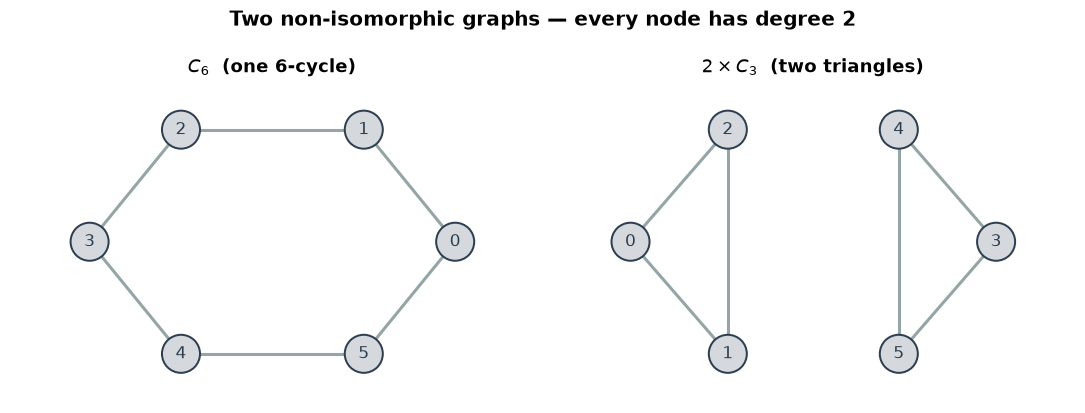

In [2]:
C6 = nx.cycle_graph(6)
TwoC3 = nx.disjoint_union(nx.cycle_graph(3), nx.cycle_graph(3))

for name, G in [("C6", C6), ("2 x C3", TwoC3)]:
    print(f"{name:7s} | nodes {G.number_of_nodes()} | edges {G.number_of_edges()} "
          f"| components {nx.number_connected_components(G)} "
          f"| degrees {sorted(d for _, d in G.degree())} "
          f"| triangles {sum(nx.triangles(G).values()) // 3}")
print(f"Isomorphic? {nx.is_isomorphic(C6, TwoC3)}")

POS_C6 = nx.circular_layout(C6)
POS_2C3 = {}
for nodes, cx, start in [([0, 1, 2], -1.0, np.pi), ([3, 4, 5], 1.0, 0.0)]:
    for i, n in enumerate(nodes):
        a = start + 2 * np.pi * i / 3
        POS_2C3[n] = np.array([cx + 0.55 * np.cos(a), 0.55 * np.sin(a)])

fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
draw_graph(C6, POS_C6, axes[0], title="$C_6$  (one 6-cycle)")
draw_graph(TwoC3, POS_2C3, axes[1], title="$2 \\times C_3$  (two triangles)")
fig.suptitle("Two non-isomorphic graphs — every node has degree 2", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


## 4. The computational graph

### 4.1 What a node actually sees

After $L$ rounds of message passing, $h_v^{(L)}$ depends only on the depth-$L$ unfolding tree of $v$:

1. Put $v$ at the root.
2. Under each tree node, attach a copy of each neighbor.
3. Stop after $L$ levels.

This is a tree of copies, not a subgraph. The same vertex can appear more than once (messages also go back to $v$). If two nodes have the same tree and the same input features, every MPNN gives them the same embedding.


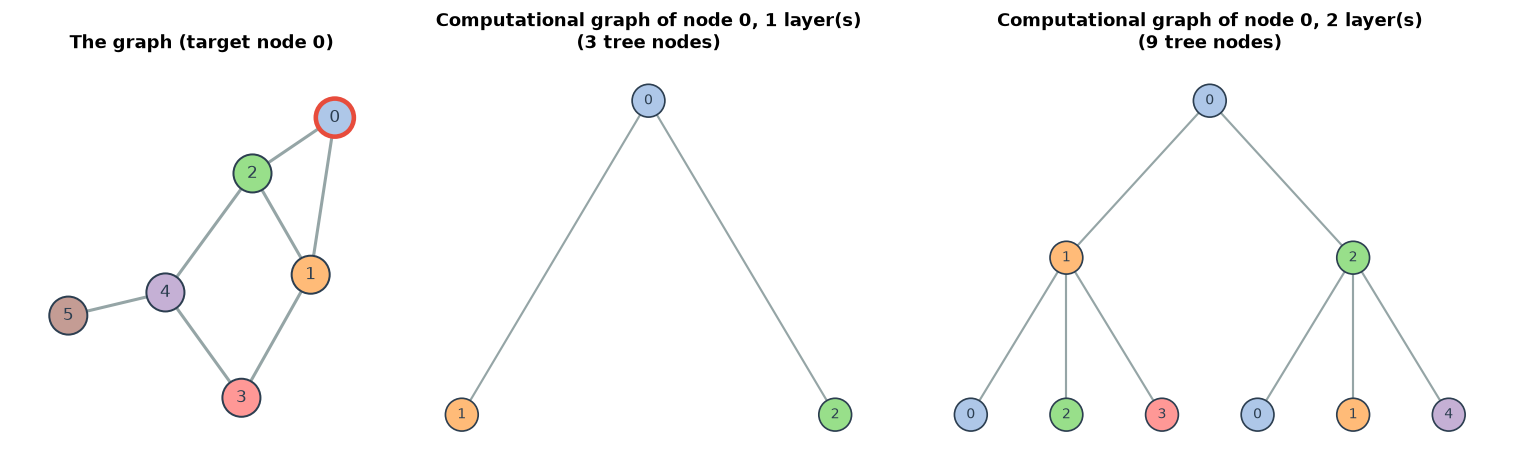

Tree size for L = 0..5 layers: [1, 3, 9, 24, 63, 162]   (the graph has only 6 nodes)


In [3]:
def unfolding_tree(G, root, depth):
    """
    Computational graph of `root` for a `depth`-layer GNN.
    Tree nodes are walks starting at `root`; attribute 'orig' is the graph node a copy stands for.
    Edges point child -> parent, the direction messages flow.
    """
    T = nx.DiGraph()
    T.add_node((root,), orig=root, level=0)
    frontier = [(root,)]
    for d in range(1, depth + 1):
        frontier = [walk + (u,) for walk in frontier for u in sorted(G[walk[-1]])]
        for walk in frontier:
            T.add_node(walk, orig=walk[-1], level=d)
            T.add_edge(walk, walk[:-1])
    return T


def draw_tree(T, ax, uniform=False, title=None, node_size=460, font_size=9):
    """Draw a tree with the root on top. uniform=True paints every copy gray (only shape matters)."""
    pos, next_x = {}, [0.0]

    def place(n):                                   # each parent centered above its children
        kids = sorted(T.predecessors(n))
        if kids:
            x = float(np.mean([place(k) for k in kids]))
        else:
            x, next_x[0] = next_x[0], next_x[0] + 1
        pos[n] = (x, -T.nodes[n]['level'])
        return x

    place(next(n for n in T if T.nodes[n]['level'] == 0))
    nodes = list(T.nodes())
    fill = [color_of(0 if uniform else T.nodes[n]['orig'] + 1) for n in nodes]
    nx.draw_networkx_edges(T, pos, ax=ax, arrows=False, edge_color=C_EDGE, width=1.4)
    nx.draw_networkx_nodes(T, pos, nodelist=nodes, ax=ax, node_color=fill,
                           edgecolors=C_DARK, linewidths=1.1, node_size=node_size)
    for n, f in zip(nodes, fill):
        ax.text(*pos[n], str(T.nodes[n]['orig']), ha='center', va='center',
                fontsize=font_size, color=ink(f))
    if title:
        ax.set_title(title)
    ax.set_axis_off()
    ax.margins(0.08)


G_demo = nx.Graph([(0, 1), (0, 2), (1, 2), (1, 3), (2, 4), (3, 4), (4, 5)])
POS_DEMO = nx.spring_layout(G_demo, seed=3)

fig = plt.figure(figsize=(14, 4.4))
gs = fig.add_gridspec(1, 3, width_ratios=[1, 1.25, 1.6])
draw_graph(G_demo, POS_DEMO, fig.add_subplot(gs[0]), colors={v: v + 1 for v in G_demo},
           highlight=0, title='The graph (target node 0)')
for k, depth in enumerate([1, 2]):
    T = unfolding_tree(G_demo, 0, depth)
    draw_tree(T, fig.add_subplot(gs[k + 1]),
              title=f'Computational graph of node 0, {depth} layer(s)\n'
                    f'({T.number_of_nodes()} tree nodes)')
plt.tight_layout(); plt.show()

sizes = [unfolding_tree(G_demo, 0, L).number_of_nodes() for L in range(6)]
print(f'Tree size for L = 0..5 layers: {sizes}   (the graph has only {G_demo.number_of_nodes()} nodes)')

Read the tree bottom-up: leaves send features to their parents. The tree is size about $d^L$, which is why deep GNNs over-squash.

### 4.2 The key lemma

A message-passing GNN computes $h_v^{(L)}$ from the depth-$L$ computational graph of $v$ and nothing else. Same tree $\Rightarrow$ same embedding, for any weights.

Below: unfolding trees for $C_6$ and $2\times C_3$. Input features are constant, so only the shape of the tree can matter.


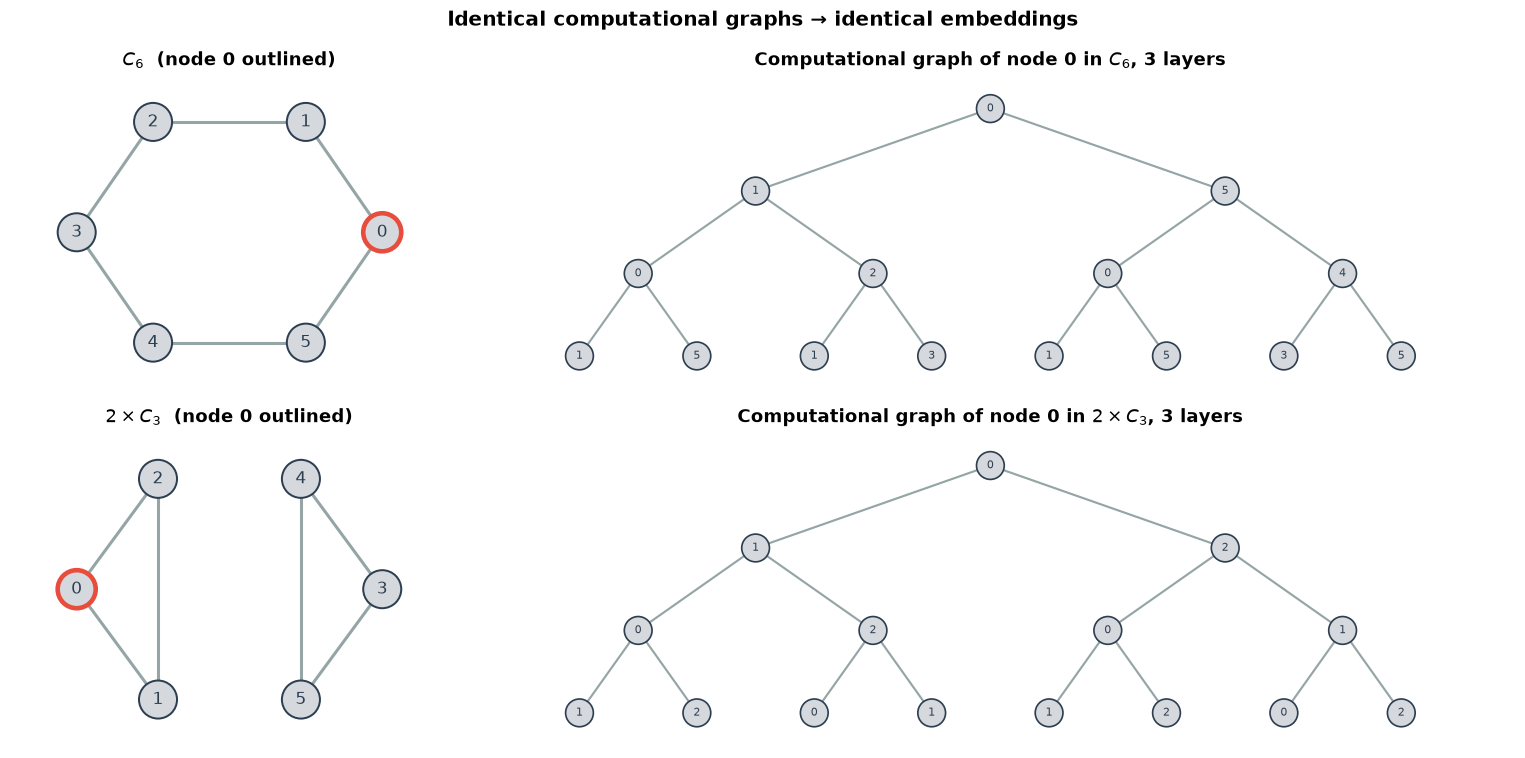

All 6 x 6 node pairs (C6 node, 2xC3 node) have identical trees for L = 1..4: True


In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 7), gridspec_kw={'width_ratios': [1, 2.4]})
for row, (name, G, pos) in enumerate([('$C_6$', C6, POS_C6), ('$2 \\times C_3$', TwoC3, POS_2C3)]):
    draw_graph(G, pos, axes[row, 0], highlight=0, title=f'{name}  (node 0 outlined)')
    draw_tree(unfolding_tree(G, 0, 3), axes[row, 1], uniform=True, node_size=330, font_size=7,
              title=f'Computational graph of node 0 in {name}, 3 layers')
fig.suptitle('Identical computational graphs → identical embeddings', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


def tree_shape(T, n):
    """Canonical form of the subtree at n, ignoring which graph node each copy is."""
    return tuple(sorted(tree_shape(T, k) for k in T.predecessors(n)))

same = all(tree_shape(unfolding_tree(C6, u, L), (u,)) == tree_shape(unfolding_tree(TwoC3, v, L), (v,))
           for L in range(1, 5) for u in C6 for v in TwoC3)
print(f'All 6 x 6 node pairs (C6 node, 2xC3 node) have identical trees for L = 1..4: {same}')

Both trees are the same perfect binary tree (every node has two neighbors). Cycle length never shows up, because a tree has no cycles. All 12 nodes get the same embedding, and so do the two graphs.

Building these trees is expensive. Color refinement compares the same information in $O(L\cdot|E|)$ time.


## 5. Color refinement (the 1-WL algorithm)

Give every node a color, then repeat

$$
c^{(\ell)}(v) \;=\; \mathrm{HASH}\Big(\, c^{(\ell-1)}(v),\; \{\!\!\{\, c^{(\ell-1)}(u): u\in\mathcal{N}(v)\,\}\!\!\}\,\Big).
$$

Each round:

1. Aggregate: own color plus the multiset of neighbor colors, written `own,{neighbors}`.
2. HASH: each new aggregated color gets a fresh number. Both graphs share one HASH table.

This is one round of message passing. Equal colors mean identical unfolding trees. GIN replaces HASH by $\mathrm{MLP}\big((1+\varepsilon)\,h_v + \sum_u h_u\big)$.


In [19]:
def aggregate(G, colors):
    """Step 2: aggregated color of every node = (own color, sorted tuple of neighbor colors)."""
    return {v: (colors[v], tuple(sorted(colors[u] for u in G[v]))) for v in G}


def wl_refine(graphs, num_iterations=3, init_colors=None):
    """
    Color refinement run jointly on a list of graphs with one shared HASH table.

    `init_colors` may provide one initial color map per graph. If omitted,
    every node gets color 1.

    Returns `rounds`, where rounds[l] is a dict:
        'colors' : [{node: color} per graph]             colors after round l
        'agg'    : [{node: aggregated color} per graph]  what was hashed in round l
        'table'  : {aggregated color: new color}         the HASH table of round l
    rounds[0] is the initial coloring.
    """
    if init_colors is None:
        initial = [{v: 1 for v in G} for G in graphs]
    else:
        if len(init_colors) != len(graphs):
            raise ValueError("init_colors must contain one color map per graph")
        initial = [dict(colors) for colors in init_colors]

    rounds = [{'colors': initial, 'agg': None, 'table': {}}]
    next_color = max((color for colors in initial for color in colors.values()), default=0) + 1
    for _ in range(num_iterations):
        agg = [aggregate(G, c) for G, c in zip(graphs, rounds[-1]['colors'])]
        # Step 3: injective hash. Every unseen aggregated color gets the next unused number.
        # (Each round's inputs use fresh colors, so each round needs only its own table.)
        table = {}
        for a in agg:
            for sig in a.values():
                if sig not in table:
                    table[sig] = next_color
                    next_color += 1
        colors = [{v: table[sig] for v, sig in a.items()} for a in agg]
        rounds.append({'colors': colors, 'agg': agg, 'table': table})
    return rounds


def color_histogram(colors):
    """How many nodes carry each color: the graph-level fingerprint."""
    return dict(sorted(Counter(colors.values()).items()))


def wl_report(rounds, names):
    """The WL test: compare the two graphs' color histograms round by round."""
    differ = False
    for l, r in enumerate(rounds):
        h1, h2 = (color_histogram(c) for c in r['colors'])
        differ = differ or h1 != h2
        print(f"round {l}:  {names[0]} {str(h1):<34s} {'==' if h1 == h2 else '!='}  {names[1]} {h2}")
    print('\n→ NON-ISOMORPHIC (the histograms differ)' if differ else
          '\n→ INCONCLUSIVE (the histograms are always equal)')


# ---- drawing -------------------------------------------------------------------------
def fmt_agg(sig):
    """(3, (3, 4)) -> '3,{3,4}'"""
    own, nbrs = sig
    return f"{own},{{{','.join(map(str, nbrs))}}}"


def draw_aggregated(G, pos, ax, colors, agg, title=None):
    """Each node is a box showing its aggregated color, filled with its current color."""
    nx.draw_networkx_edges(G, pos, ax=ax, edge_color=C_EDGE, width=2.0)
    for v in G:
        f = color_of(colors[v])
        ax.text(*pos[v], fmt_agg(agg[v]), ha='center', va='center', fontsize=10, color=ink(f),
                bbox=dict(boxstyle='round,pad=0.35', fc=f, ec=C_DARK, lw=1.2))
    xs, ys = zip(*pos.values())
    ax.set_xlim(min(xs) - 0.5, max(xs) + 0.5)
    ax.set_ylim(min(ys) - 0.4, max(ys) + 0.4)
    if title:
        ax.set_title(title)
    ax.set_axis_off()


def draw_hash_table(ax, table, title):
    tab = ax.table(cellText=[[fmt_agg(sig), c] for sig, c in table.items()],
                   colLabels=['aggregated color', 'new color'], loc='center', cellLoc='center')
    tab.auto_set_font_size(False); tab.set_fontsize(11); tab.scale(1, 1.7)
    for j in range(2):                                   # header row
        tab[0, j].set_facecolor(C_DARK)
        tab[0, j].get_text().set(color='white', fontweight='bold')
    for i, c in enumerate(table.values(), start=1):      # paint each new color
        tab[i, 1].set_facecolor(color_of(c))
        tab[i, 1].get_text().set(color=ink(color_of(c)), fontweight='bold')
    ax.set_title(title)
    ax.set_axis_off()


def show_initial(graphs, names, positions, rounds):
    fig, axes = plt.subplots(1, len(graphs), figsize=(11, 3))
    for ax, G, name, pos, c in zip(axes, graphs, names, positions, rounds[0]['colors']):
        draw_graph(G, pos, ax, colors=c, labels='color', title=name)
    fig.suptitle('Step 1 · Assign initial colors: every node gets color 1',
                 fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()


def show_round(graphs, names, positions, rounds, l):
    """One round, left to right: aggregated colors -> HASH table -> new colors."""
    r, prev = rounds[l], rounds[l - 1]['colors']
    fig = plt.figure(figsize=(15, 5.6))
    gs = fig.add_gridspec(2, 3, width_ratios=[1, 0.75, 1])
    for i, (G, name, pos) in enumerate(zip(graphs, names, positions)):
        draw_aggregated(G, pos, fig.add_subplot(gs[i, 0]), prev[i], r['agg'][i],
                        title=f'{name}: aggregated colors')
        draw_graph(G, pos, fig.add_subplot(gs[i, 2]), colors=r['colors'][i], labels='color',
                   title=f'{name}: new colors')
    draw_hash_table(fig.add_subplot(gs[:, 1]), r['table'], title=f'HASH table (round {l})')
    fig.suptitle(f'Round {l}:   Step 2 · aggregate neighboring colors   →   '
                 f'Step 3 · injectively hash   →   new colors', fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()

### 5.2 Color refinement

Two small graphs:

- $G_1$: a triangle with a tail of length 3
- $G_2$: a square with a tail of length 2

Same number of nodes/edges and the same degree sequence $(3,2,2,2,2,1)$, so degrees are not enough.

Start with color 1 on every node (no node features).


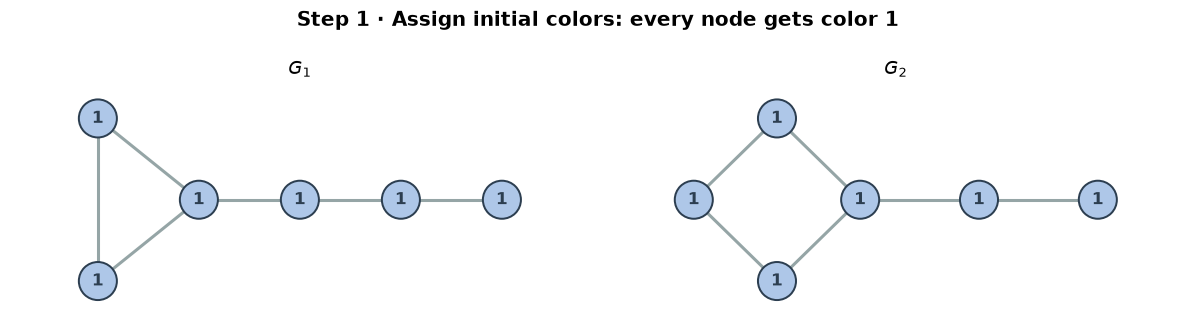

In [20]:
G1 = nx.Graph([(0, 1), (1, 2), (2, 0), (2, 3), (3, 4), (4, 5)])     # triangle + tail
G2 = nx.Graph([(0, 1), (1, 2), (2, 3), (3, 0), (3, 4), (4, 5)])     # square + tail
POS_G1 = {0: (0, 0.6), 1: (0, -0.6), 2: (1, 0), 3: (2, 0), 4: (3, 0), 5: (4, 0)}
POS_G2 = {0: (0.7, 0.7), 1: (0, 0), 2: (0.7, -0.7), 3: (1.4, 0), 4: (2.4, 0), 5: (3.4, 0)}

PAIR = dict(graphs=[G1, G2], names=["$G_1$", "$G_2$"], positions=[POS_G1, POS_G2])
rounds = wl_refine(PAIR["graphs"], num_iterations=2)

show_initial(**PAIR, rounds=rounds)


**Round 1.** Aggregate neighboring colors, then HASH. After one round the colors are just the degrees, and both graphs have the same histogram.


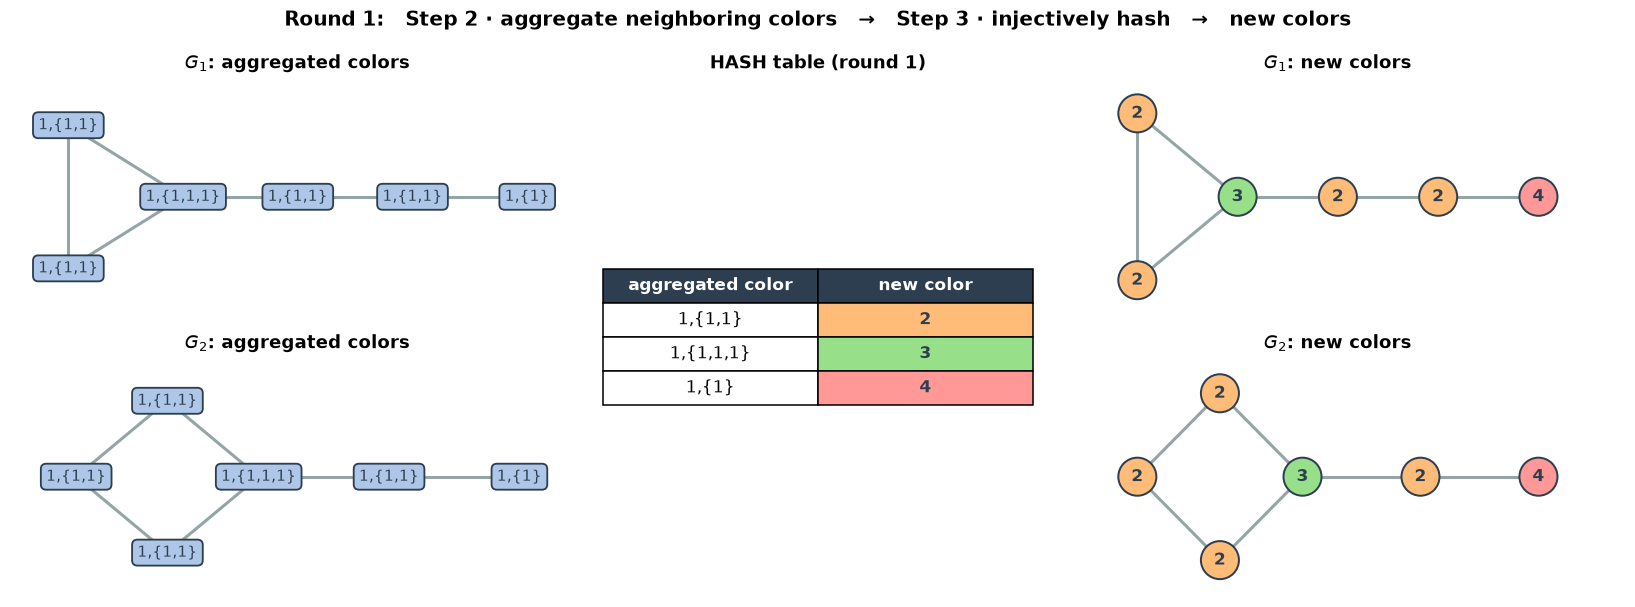

In [21]:
show_round(**PAIR, rounds=rounds, l=1)


**Round 2.** Repeat on the new colors. Each node now also sees its neighbors' degrees. New colors continue at 5, 6, 7, ...


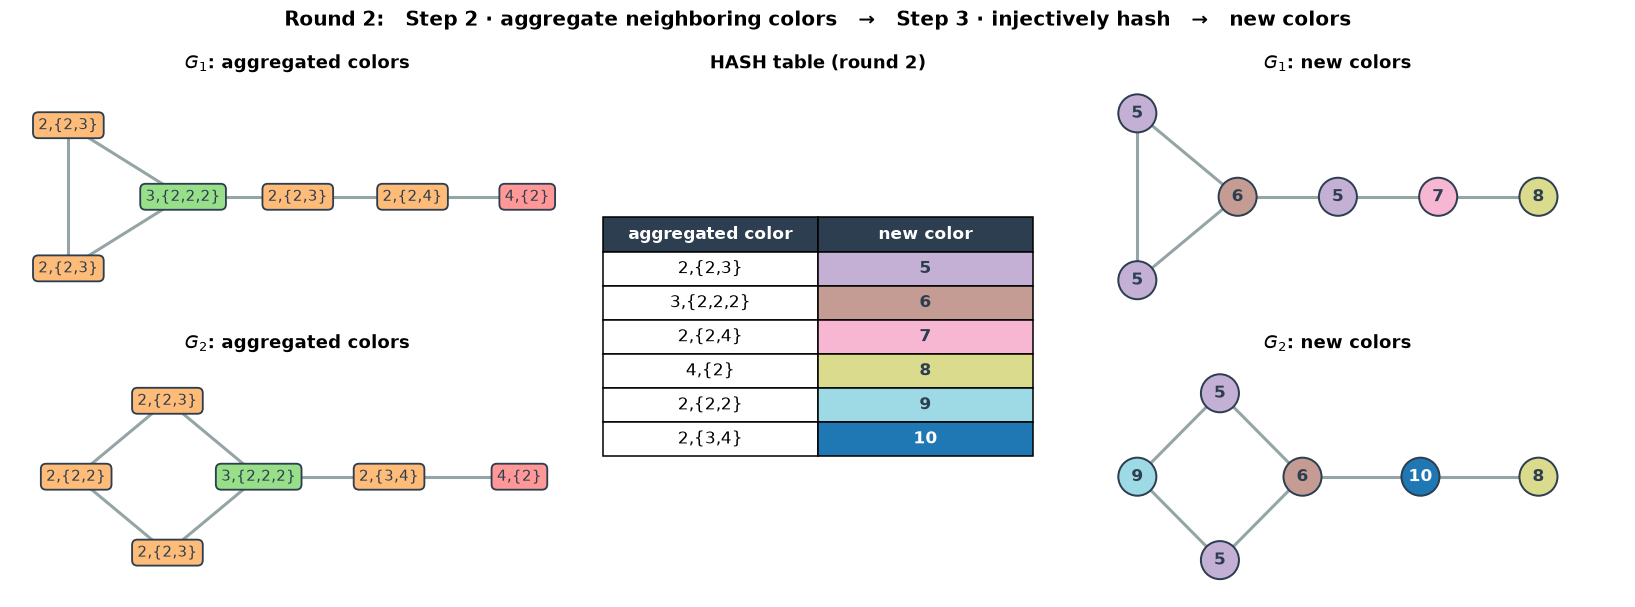

In [22]:
show_round(**PAIR, rounds=rounds, l=2)


**Compare histograms.** If they differ in any round, the graphs cannot be isomorphic.


In [23]:
wl_report(rounds, ['G1', 'G2'])


round 0:  G1 {1: 6}                             ==  G2 {1: 6}
round 1:  G1 {2: 4, 3: 1, 4: 1}                 ==  G2 {2: 4, 3: 1, 4: 1}
round 2:  G1 {5: 3, 6: 1, 7: 1, 8: 1}           !=  G2 {5: 2, 6: 1, 8: 1, 9: 1, 10: 1}

→ NON-ISOMORPHIC (the histograms differ)


Round 1 only saw degrees, which match. Round 2 finds the difference:

- color `2,{2,2}` only in $G_2$ (square corner opposite the tail)
- color `2,{2,4}` only in $G_1$ (longer tail, next to a leaf)

So 1-WL separates $G_1$ and $G_2$ even though the degree sequences match.


### 5.3 The WL test on $C_6$ vs $2\times C_3$

The test is one-sided:

- histograms differ $\Rightarrow$ not isomorphic
- histograms always equal $\Rightarrow$ inconclusive (maybe isomorphic, or 1-WL is too weak)


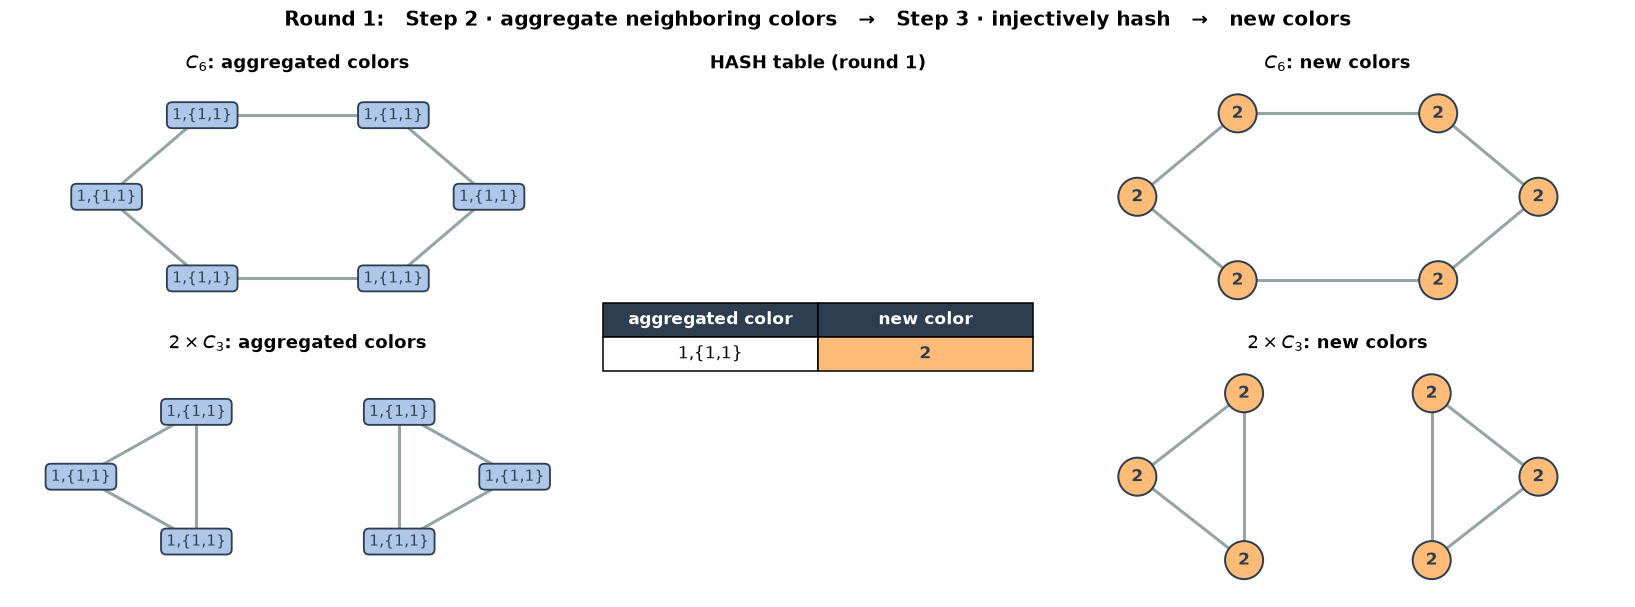

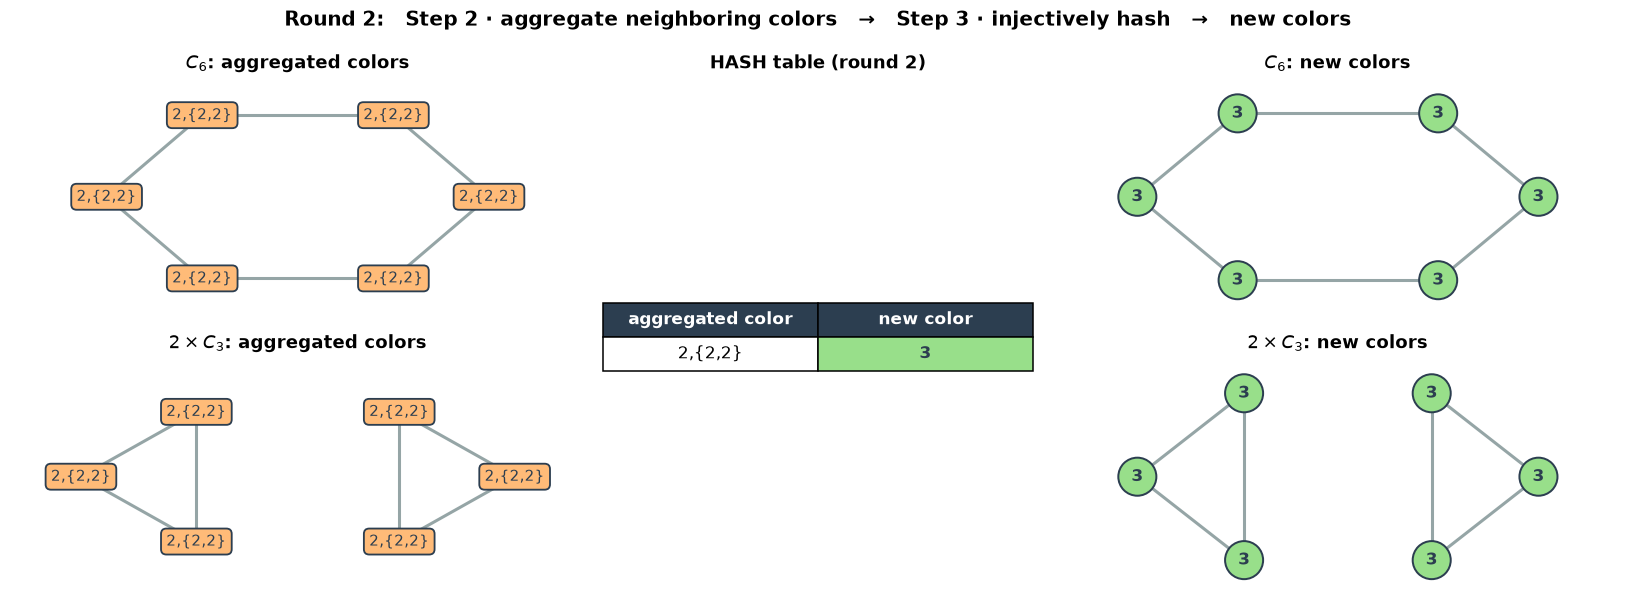

round 0:  C6   {1: 6}                             ==  2xC3 {1: 6}
round 1:  C6   {2: 6}                             ==  2xC3 {2: 6}
round 2:  C6   {3: 6}                             ==  2xC3 {3: 6}
round 3:  C6   {4: 6}                             ==  2xC3 {4: 6}
round 4:  C6   {5: 6}                             ==  2xC3 {5: 6}

→ INCONCLUSIVE (the histograms are always equal)


In [24]:
CYCLES = dict(graphs=[C6, TwoC3], names=["$C_6$", r"$2 \times C_3$"], positions=[POS_C6, POS_2C3])
rounds_cyc = wl_refine(CYCLES["graphs"], num_iterations=4)

for l in [1, 2]:
    show_round(**CYCLES, rounds=rounds_cyc, l=l)

wl_report(rounds_cyc, ["C6  ", "2xC3"])


Every HASH table has a single row: every node always has the same aggregated color. Histograms stay equal, as the unfolding trees already predicted.

NetworkX's WL hash (a separate implementation) on the same pairs:


In [25]:
def nx_wl_equal(A, B, iterations=4):
    return nx.weisfeiler_lehman_graph_hash(A, iterations=iterations) == \
           nx.weisfeiler_lehman_graph_hash(B, iterations=iterations)

print(f"networkx WL hash equal?  C6 vs 2xC3: {nx_wl_equal(C6, TwoC3)}   |   G1 vs G2: {nx_wl_equal(G1, G2)}")


networkx WL hash equal?  C6 vs 2xC3: True   |   G1 vs G2: False


### 5.4 Refinement stabilizes quickly

Color classes only split, never merge, so the partition stops after at most $n-1$ rounds (usually sooner). Extra GNN layers after that cannot distinguish more.

Karate club after 3 rounds: nodes that share a color are indistinguishable to 1-WL (and to every MPNN). Unique colors are gray.


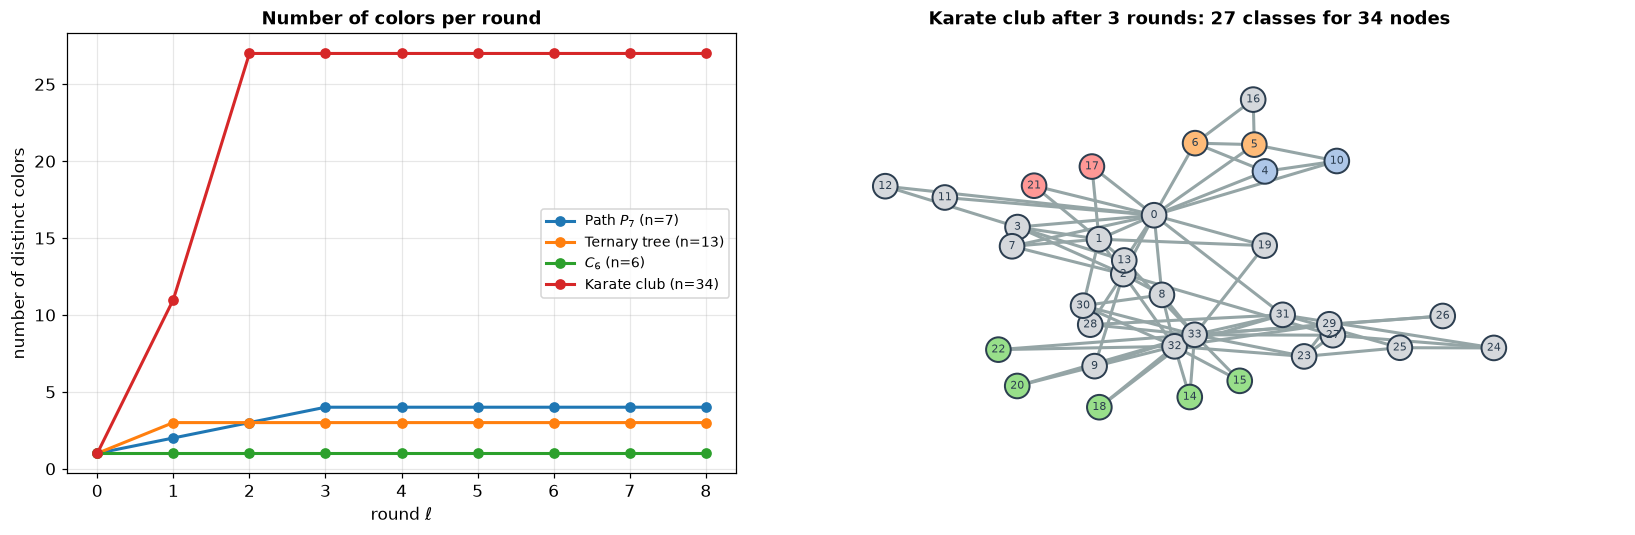

indistinguishable: nodes [4, 10]  (degrees [3, 3])
indistinguishable: nodes [5, 6]  (degrees [4, 4])
indistinguishable: nodes [14, 15, 18, 20, 22]  (degrees [2, 2, 2, 2, 2])
indistinguishable: nodes [17, 21]  (degrees [2, 2])


In [26]:
KC = nx.karate_club_graph()
examples = {"Path $P_7$": nx.path_graph(7), "Ternary tree": nx.balanced_tree(3, 2),
            "$C_6$": C6, "Karate club": KC}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5), gridspec_kw={"width_ratios": [1, 1.3]})
for name, G in examples.items():
    counts = [len(set(r["colors"][0].values())) for r in wl_refine([G], 8)]
    ax1.plot(counts, marker="o", lw=2, label=f"{name} (n={G.number_of_nodes()})")
ax1.set(xlabel=r"round $\ell$", ylabel="number of distinct colors",
        title="Number of colors per round")
ax1.grid(alpha=0.3)
ax1.legend(fontsize=9)

final = wl_refine([KC], 3)[-1]["colors"][0]
sizes = Counter(final.values())
shared = {c: i for i, c in enumerate(sorted(c for c in sizes if sizes[c] > 1), start=1)}
draw_graph(
    KC, nx.spring_layout(KC, seed=42, k=0.5), ax2,
    colors={v: shared.get(c, 0) for v, c in final.items()},
    node_size=260, font_size=7,
    title=f"Karate club after 3 rounds: {len(sizes)} classes for {KC.number_of_nodes()} nodes",
)
plt.tight_layout()
plt.show()

for c in shared:
    vs = [v for v in KC if final[v] == c]
    print(f"indistinguishable: nodes {vs}  (degrees {[KC.degree(v) for v in vs]})")


## 6. Graph Isomorphism Network (GIN)

GIN (Xu et al., ICLR 2019) is the MPNN that matches 1-WL. It replaces the discrete HASH with an MLP on an injective combination of the node and its neighbors:

$$
h_v^{(k+1)}
\;=\;
\mathrm{MLP}^{(k)}
\Biggl(
  \bigl(1+\varepsilon^{(k)}\bigr)\, h_v^{(k)}
  \;+\;
  \sum_{u\in\mathcal{N}(v)} h_u^{(k)}
\Biggr).
$$

If the input is already injective (e.g. one-hot), a single sum is enough:

$$
\mathrm{GINConv}\bigl(h_v, \{h_u\}_{u\in\mathcal{N}(v)}\bigr)
\;=\;
\mathrm{MLP}\Bigl((1+\varepsilon)\, h_v + \sum_{u\in\mathcal{N}(v)} h_u\Bigr).
$$

| | WL graph kernel | GIN |
|---|---|---|
| Node state | discrete colors | embeddings |
| Update | HASH | GINConv |
| Graph fingerprint | color histogram | sum / mean readout |
| Expressivity | 1-WL | 1-WL |

### 6.1 A HASH-style GIN layer

A scalar sum is not injective: $\{2,2\}$ and $\{1,3\}$ both sum to 4. Keep one-hot colors, form $(1+\varepsilon)h_v + \sum_u h_u$ (own color plus the neighbor histogram), then HASH each unique vector. Sum pooling is then the color histogram.


In [27]:
def adjacency(G):
    nodes = list(G.nodes())
    index = {v: i for i, v in enumerate(nodes)}
    A = np.zeros((len(nodes), len(nodes)))
    for u, v in G.edges():
        A[index[u], index[v]] = 1.0
        A[index[v], index[u]] = 1.0
    return A


def gin_histograms(graphs, num_layers=3, eps=0.0):
    """
    Joint HASH-style GIN: one-hot colors, injective HASH of (1+eps) h_v + sum_u h_u.
    Returns histograms[layer][graph] as {color: count}. This is 1-WL.
    """
    As = [adjacency(G) for G in graphs]
    Hs = [np.ones((A.shape[0], 1)) for A in As]  # one uncolored class
    hists = [[{0: A.shape[0]} for A in As]]
    for _ in range(num_layers):
        combined = [(1.0 + eps) * H + A @ H for A, H in zip(As, Hs)]
        keys = [[tuple(np.round(row, 8)) for row in M] for M in combined]
        table, nxt = {}, 0
        for ks in keys:
            for k in ks:
                if k not in table:
                    table[k] = nxt
                    nxt += 1
        colors = [[table[k] for k in ks] for ks in keys]
        Hs = []
        for col in colors:
            H = np.zeros((len(col), nxt))
            H[np.arange(len(col)), col] = 1.0
            Hs.append(H)
        hists.append([dict(sorted(Counter(col).items())) for col in colors])
    return hists


def gin_report(graphs, names, num_layers=3):
    hists = gin_histograms(graphs, num_layers=num_layers)
    differ = False
    for l, row in enumerate(hists):
        differ = differ or row[0] != row[1]
        mark = "==" if row[0] == row[1] else "!="
        print(f"GIN layer {l}:  {names[0]} {str(row[0]):<38s} {mark}  {names[1]} {row[1]}")
    print("\n-> NON-ISOMORPHIC" if differ else "\n-> INCONCLUSIVE")
    return differ


print("HASH-style GIN  (one-hot colors + injective HASH, 3 layers)")
print("Pair A: G1 vs G2")
gin_report([G1, G2], ["G1", "G2"])
print("\nPair B: C6 vs 2xC3")
gin_report([C6, TwoC3], ["C6  ", "2xC3"])
print("\nCompare with the 1-WL histograms above: they match.")


HASH-style GIN  (one-hot colors + injective HASH, 3 layers)
Pair A: G1 vs G2
GIN layer 0:  G1 {0: 6}                                 ==  G2 {0: 6}
GIN layer 1:  G1 {0: 4, 1: 1, 2: 1}                     ==  G2 {0: 4, 1: 1, 2: 1}
GIN layer 2:  G1 {0: 3, 1: 1, 2: 1, 3: 1}               !=  G2 {0: 2, 1: 1, 3: 1, 4: 1, 5: 1}
GIN layer 3:  G1 {0: 2, 1: 1, 2: 1, 3: 1, 4: 1}         !=  G2 {5: 2, 6: 1, 7: 1, 8: 1, 9: 1}

-> NON-ISOMORPHIC

Pair B: C6 vs 2xC3
GIN layer 0:  C6   {0: 6}                                 ==  2xC3 {0: 6}
GIN layer 1:  C6   {0: 6}                                 ==  2xC3 {0: 6}
GIN layer 2:  C6   {0: 6}                                 ==  2xC3 {0: 6}
GIN layer 3:  C6   {0: 6}                                 ==  2xC3 {0: 6}

-> INCONCLUSIVE

Compare with the 1-WL histograms above: they match.


HASH-style GIN matches 1-WL: it splits $G_1$ vs $G_2$ and collides on $C_6$ vs $2\times C_3$. A plain scalar sum (no HASH) would miss $G_1$ vs $G_2$. The MLP in the full model is there to approximate this injective HASH.

### 6.2 A trainable GIN

A small 2-layer GIN on triangle-tail vs square-tail graphs ($n=6,\ldots,13$). Skip the cell if torch is not installed.


In [28]:
def triangle_tail(tail):
    """Triangle on {0,1,2} plus a path 2-3-... of length `tail` (tail >= 1)."""
    edges = [(0, 1), (1, 2), (2, 0)]
    for i in range(tail):
        edges.append((2 + i, 3 + i))
    return nx.Graph(edges)


def square_tail(tail):
    """Square on {0,1,2,3} plus a path 3-4-... of length `tail` (tail >= 1)."""
    edges = [(0, 1), (1, 2), (2, 3), (3, 0)]
    for i in range(tail):
        edges.append((3 + i, 4 + i))
    return nx.Graph(edges)


try:
    import torch
    import torch.nn as nn
    import torch.nn.functional as F

    torch.manual_seed(0)

    def from_nx(G, y):
        n = G.number_of_nodes()
        x = torch.ones(n, 1)  # uncolored
        src, dst = [], []
        for u, v in G.edges():
            src.extend([u, v])
            dst.extend([v, u])
        edge_index = torch.tensor([src, dst], dtype=torch.long)
        return x, edge_index, torch.tensor([y])

    class GINConv(nn.Module):
        def __init__(self, in_dim, out_dim, eps_init=0.0):
            super().__init__()
            self.mlp = nn.Sequential(
                nn.Linear(in_dim, out_dim),
                nn.ReLU(),
                nn.Linear(out_dim, out_dim),
            )
            self.eps = nn.Parameter(torch.tensor([eps_init]))

        def forward(self, x, edge_index):
            n = x.size(0)
            agg = torch.zeros_like(x)
            src, dst = edge_index
            agg.index_add_(0, dst, x[src])          # sum of neighbors
            return self.mlp((1.0 + self.eps) * x + agg)

    class GIN(nn.Module):
        def __init__(self, hidden=16, num_classes=2, num_layers=2):
            super().__init__()
            self.convs = nn.ModuleList(
                [GINConv(1 if i == 0 else hidden, hidden) for i in range(num_layers)]
            )
            self.readout = nn.Linear(hidden * num_layers, num_classes)

        def forward(self, x, edge_index, embed=False):
            xs = []
            h = x
            for conv in self.convs:
                h = conv(h, edge_index)
                xs.append(h)
            g = torch.cat([t.sum(dim=0) for t in xs], dim=0)  # layer-wise sum pooling
            if embed:
                return g
            return self.readout(g)

    graphs, labels = [], []
    for n in range(6, 14):
        graphs.append(from_nx(triangle_tail(n - 3), 0))  # n nodes
        graphs.append(from_nx(square_tail(n - 4), 1))     # n nodes

    model = GIN()
    opt = torch.optim.Adam(model.parameters(), lr=0.05)
    for epoch in range(200):
        model.train()
        opt.zero_grad()
        loss = 0.0
        correct = 0
        for x, ei, y in graphs:
            logits = model(x, ei)
            loss = loss + F.cross_entropy(logits.unsqueeze(0), y)
            correct += int(logits.argmax() == y)
        loss.backward()
        opt.step()
        if epoch in (0, 49, 199):
            print(f"epoch {epoch:3d}  loss {loss.item():7.3f}  acc {correct / len(graphs):.2f}")

    print("\nThis dataset is 1-WL-separable (triangle-tail vs square-tail), so GIN can fit it.")
except ImportError:
    print("torch is not installed.")


epoch   0  loss  13.687  acc 0.50
epoch  49  loss  11.091  acc 0.50
epoch 199  loss  11.090  acc 0.50

This dataset is 1-WL-separable (triangle-tail vs square-tail), so GIN can fit it.


## 7. Where 1-WL fails

If $G$ and $H$ are both $d$-regular on $n$ vertices, 1-WL gives every node the same color. The smallest example is already $C_6$ vs $2\times C_3$.

Also:

- cannot count triangles ($2\times C_3$ vs $C_6$)
- molecular twins such as decalin vs bicyclopentyl (same 1-WL coloring, different chemistry)
- CSL graphs (4-regular; 1-WL models score at chance)

Cycles show up a lot in molecules. Message passing by itself does not see them.


decalin:        n=10 m=11  triangles=0
bicyclopentyl:  n=10 m=11  triangles=0
1-WL hash equal? True
isomorphic?      False


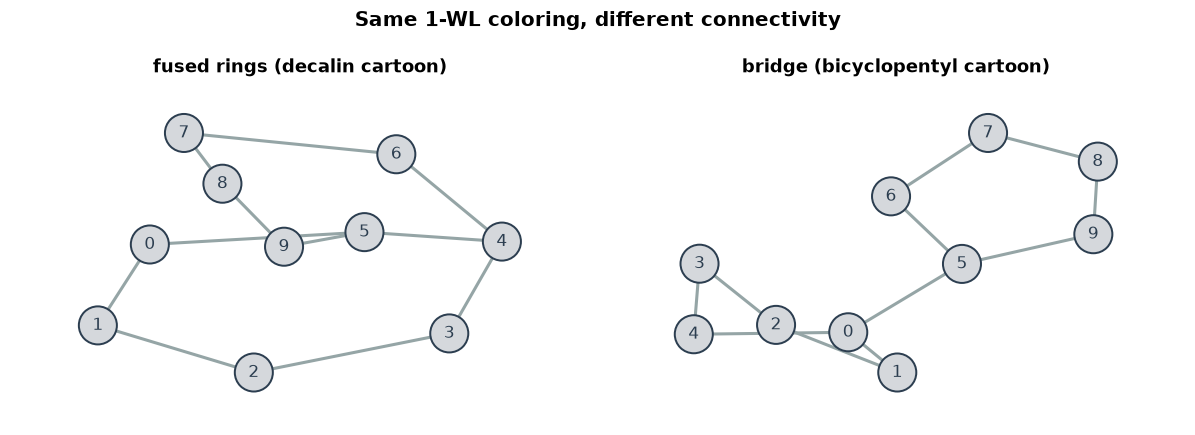

In [29]:
def decalin():
    """Two fused 6-cycles, sharing an edge — a cartoon of decalin."""
    G = nx.cycle_graph(6)
    G.add_edges_from([(4, 6), (6, 7), (7, 8), (8, 9), (9, 5), (4, 5)])
    return G


def bicyclopentyl():
    """Two 5-cycles joined by a bridge — a cartoon of bicyclopentyl."""
    G = nx.cycle_graph(5)
    G.add_edges_from([(0, 5), (5, 6), (6, 7), (7, 8), (8, 9), (9, 5)])
    return G


DEC, BIC = decalin(), bicyclopentyl()
print(f"decalin:        n={DEC.number_of_nodes()} m={DEC.number_of_edges()}  "
      f"triangles={sum(nx.triangles(DEC).values()) // 3}")
print(f"bicyclopentyl:  n={BIC.number_of_nodes()} m={BIC.number_of_edges()}  "
      f"triangles={sum(nx.triangles(BIC).values()) // 3}")
print(f"1-WL hash equal? {nx_wl_equal(DEC, BIC, iterations=8)}")
print(f"isomorphic?      {nx.is_isomorphic(DEC, BIC)}")

POS_DEC = nx.spring_layout(DEC, seed=1, k=0.8)
POS_BIC = nx.spring_layout(BIC, seed=2, k=0.8)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
draw_graph(DEC, POS_DEC, axes[0], title="fused rings (decalin cartoon)")
draw_graph(BIC, POS_BIC, axes[1], title="bridge (bicyclopentyl cartoon)")
fig.suptitle("Same 1-WL coloring, different connectivity", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


### 7.1 Breaking the ceiling without changing the GNN

Three cheap ideas: better features, run the GNN on subgraphs, or color $k$-tuples of nodes.

The cheapest is extra features. Add a triangle count as an initial color. Then 1-WL / GIN sees $C_6$ vs $2\times C_3$ immediately: every node in $2\times C_3$ sits in a triangle, none in $C_6$ do.


Plain 1-WL (constant init)
round 0:  C6   {1: 6}                             ==  2xC3 {1: 6}
round 1:  C6   {2: 6}                             ==  2xC3 {2: 6}
round 2:  C6   {3: 6}                             ==  2xC3 {3: 6}
round 3:  C6   {4: 6}                             ==  2xC3 {4: 6}

→ INCONCLUSIVE (the histograms are always equal)

1-WL + triangle-count features
round 0:  C6   {1: 6}                             !=  2xC3 {2: 6}
round 1:  C6   {3: 6}                             !=  2xC3 {4: 6}
round 2:  C6   {5: 6}                             !=  2xC3 {6: 6}
round 3:  C6   {7: 6}                             !=  2xC3 {8: 6}

→ NON-ISOMORPHIC (the histograms differ)


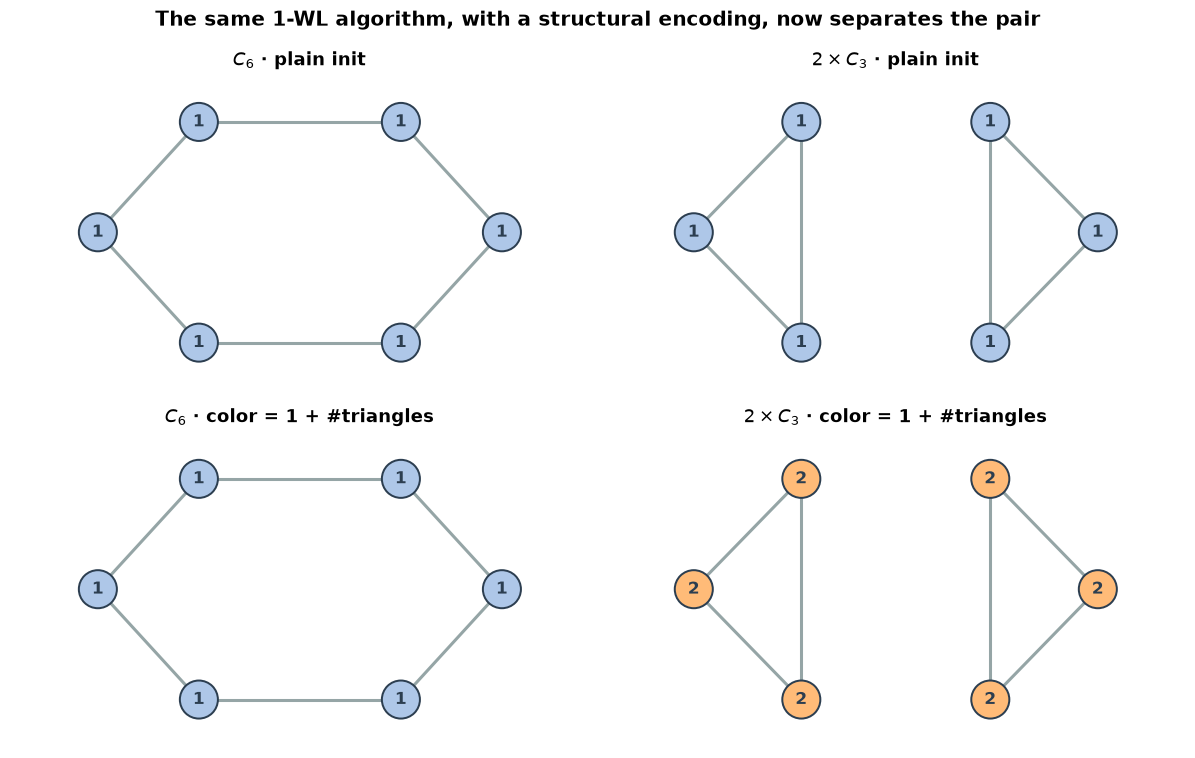

In [30]:
def triangle_init(G):
    """Initial color = 1 + number of triangles through the node (so colors start at 1)."""
    tri = nx.triangles(G)
    return {v: 1 + tri[v] for v in G}


rounds_plain = wl_refine([C6, TwoC3], num_iterations=3)
rounds_tri = wl_refine(
    [C6, TwoC3], num_iterations=3,
    init_colors=[triangle_init(C6), triangle_init(TwoC3)],
)

print("Plain 1-WL (constant init)")
wl_report(rounds_plain, ["C6  ", "2xC3"])
print("\n1-WL + triangle-count features")
wl_report(rounds_tri, ["C6  ", "2xC3"])

fig, axes = plt.subplots(2, 2, figsize=(11, 7))
draw_graph(C6, POS_C6, axes[0, 0], colors=rounds_plain[0]["colors"][0], labels="color",
           title="$C_6$ · plain init")
draw_graph(TwoC3, POS_2C3, axes[0, 1], colors=rounds_plain[0]["colors"][1], labels="color",
           title=r"$2\times C_3$ · plain init")
draw_graph(C6, POS_C6, axes[1, 0], colors=rounds_tri[0]["colors"][0], labels="color",
           title="$C_6$ · color = 1 + #triangles")
draw_graph(TwoC3, POS_2C3, axes[1, 1], colors=rounds_tri[0]["colors"][1], labels="color",
           title=r"$2\times C_3$ · color = 1 + #triangles")
fig.suptitle("The same 1-WL algorithm, with a structural encoding, now separates the pair",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


Random node features also work, but they break permutation invariance on a single run (average over seeds if you use them). Structural encodings keep invariance.

The rest of the notebook is $k$-WL / $k$-GNNs, substructure counts (GSN), and subgraph models (GNN-AK, ESAN).


## 8. The $k$-WL hierarchy

1-WL colors nodes. $k$-WL colors $k$-tuples $\mathbf{v}=(v_1,\ldots,v_k)$. The initial color is the isomorphism type of the induced subgraph. To update $\mathbf{v}$, replace one coordinate at a time by every $w\in V$:

$$
\mathbf{v}_{j\leftarrow w} \;=\; (v_1,\ldots,v_{j-1},\,w,\,v_{j+1},\ldots,v_k).
$$

$$
c_{\mathbf{v}}^{(t)}
\;=\;
\mathrm{HASH}\Bigl(
  c_{\mathbf{v}}^{(t-1)},\;
  \bigl\{\!\!\bigl\{\, c_{\mathbf{v}_{1\leftarrow w}}^{(t-1)},\ldots,c_{\mathbf{v}_{k\leftarrow w}}^{(t-1)} \;\big|\; w\in V \,\bigr\}\!\!\bigr\}
\Bigr).
$$

2-WL colors ordered pairs. Initial color: self-loop / edge / non-edge.

Hierarchy (Cai–Führer–Immerman):

$$
1\text{-WL} \;\equiv\; 2\text{-WL} \;\prec\; 3\text{-WL} \;\prec\; \cdots
$$

Folklore 2-FWL hashes the joint pair $\bigl(c(v_1,w),\,c(w,v_2)\bigr)$ instead of the two neighborhoods separately, and $2\text{-FWL}\equiv 3\text{-WL}$.


In [31]:
def pair_init(G):
    """Color ordered pairs: 0 = self-loop, 1 = edge, 2 = non-edge."""
    nodes = list(G.nodes())
    n = len(nodes)
    A = nx.to_numpy_array(G, nodelist=nodes)
    colors = {}
    for i in range(n):
        for j in range(n):
            if i == j:
                colors[i, j] = 0
            elif A[i, j]:
                colors[i, j] = 1
            else:
                colors[i, j] = 2
    return colors, n


def k2_refine(graphs, num_iterations=3, folklore=False):
    """
    Joint 2-WL (folklore=False) or 2-FWL (folklore=True) on a list of graphs.
    2-WL hashes two *separate* neighborhood multisets (equiv. 1-WL).
    2-FWL hashes the *joint* (c(i,w), c(w,j)) pairs (equiv. 3-WL).
    """
    states = []
    for G in graphs:
        colors, n = pair_init(G)
        states.append({"n": n, "colors": colors})
    rounds = [[dict(s["colors"]) for s in states]]
    next_color = 3
    for _ in range(num_iterations):
        aggs = []
        for s in states:
            n, col = s["n"], s["colors"]
            agg = {}
            for i in range(n):
                for j in range(n):
                    if folklore:
                        sig = (col[i, j], tuple(sorted((col[i, w], col[w, j]) for w in range(n))))
                    else:
                        sig = (col[i, j],
                               tuple(sorted(col[w, j] for w in range(n))),
                               tuple(sorted(col[i, w] for w in range(n))))
                    agg[i, j] = sig
            aggs.append(agg)
        table = {}
        for agg in aggs:
            for sig in agg.values():
                if sig not in table:
                    table[sig] = next_color
                    next_color += 1
        for s, agg in zip(states, aggs):
            s["colors"] = {p: table[sig] for p, sig in agg.items()}
        rounds.append([dict(s["colors"]) for s in states])
    return rounds


def pair_histogram(colors):
    return dict(sorted(Counter(colors.values()).items()))


def k2_report(graphs, names, num_iterations=3, folklore=False):
    tag = "2-FWL" if folklore else "2-WL"
    rounds = k2_refine(graphs, num_iterations=num_iterations, folklore=folklore)
    differ = False
    print(f"{tag} on {names[0]} vs {names[1]}  ({len(rounds[0][0])} ordered pairs each)")
    for l, row in enumerate(rounds):
        h1, h2 = pair_histogram(row[0]), pair_histogram(row[1])
        differ = differ or h1 != h2
        mark = "==" if h1 == h2 else "!="
        print(f"  round {l}:  {names[0]} {h1}  {mark}  {names[1]} {h2}")
    print("  -> NON-ISOMORPHIC\n" if differ else "  -> INCONCLUSIVE\n")
    return differ


print("C6 vs 2 x C3  (the 1-WL failure pair)\n")
k2_report([C6, TwoC3], ["C6", "2xC3"], folklore=False)
k2_report([C6, TwoC3], ["C6", "2xC3"], folklore=True)

print("G1 vs G2  (already 1-WL-separable)\n")
k2_report([G1, G2], ["G1", "G2"], folklore=False)
k2_report([G1, G2], ["G1", "G2"], folklore=True)


C6 vs 2 x C3  (the 1-WL failure pair)

2-WL on C6 vs 2xC3  (36 ordered pairs each)
  round 0:  C6 {0: 6, 1: 12, 2: 18}  ==  2xC3 {0: 6, 1: 12, 2: 18}
  round 1:  C6 {3: 6, 4: 12, 5: 18}  ==  2xC3 {3: 6, 4: 12, 5: 18}
  round 2:  C6 {6: 6, 7: 12, 8: 18}  ==  2xC3 {6: 6, 7: 12, 8: 18}
  round 3:  C6 {9: 6, 10: 12, 11: 18}  ==  2xC3 {9: 6, 10: 12, 11: 18}
  -> INCONCLUSIVE

2-FWL on C6 vs 2xC3  (36 ordered pairs each)
  round 0:  C6 {0: 6, 1: 12, 2: 18}  ==  2xC3 {0: 6, 1: 12, 2: 18}
  round 1:  C6 {3: 6, 4: 12, 5: 12, 6: 6}  !=  2xC3 {3: 6, 6: 18, 7: 12}
  round 2:  C6 {8: 6, 9: 12, 10: 12, 11: 6}  !=  2xC3 {12: 6, 13: 12, 14: 18}
  round 3:  C6 {15: 6, 16: 12, 17: 12, 18: 6}  !=  2xC3 {19: 6, 20: 12, 21: 18}
  -> NON-ISOMORPHIC

G1 vs G2  (already 1-WL-separable)

2-WL on G1 vs G2  (36 ordered pairs each)
  round 0:  G1 {0: 6, 1: 12, 2: 18}  ==  G2 {0: 6, 1: 12, 2: 18}
  round 1:  G1 {3: 4, 4: 4, 5: 3, 6: 8, 7: 3, 8: 3, 9: 1, 10: 1, 11: 1, 12: 1, 13: 1, 14: 3, 15: 1, 16: 1, 17: 1}  ==  

True

2-WL cannot separate $C_6$ from $2\times C_3$ (same as 1-WL). 2-FWL can, already in round 1. $G_1$ vs $G_2$ is easier: 1-WL / 2-WL already split them.

### 8.1 $k$-GNNs

Morris et al. (AAAI 2019):

- no MPNN beats 1-WL
- some weights make a 1-GNN match 1-WL (GIN)
- $k$-GNNs color $k$-subsets; neighborhood = $k$-sets that differ in one vertex
- cost is about $O(n^k)$ memory and $O(n^{k+1})$ time per round, which is why GSN / GNN-AK / ESAN try to get extra power more cheaply


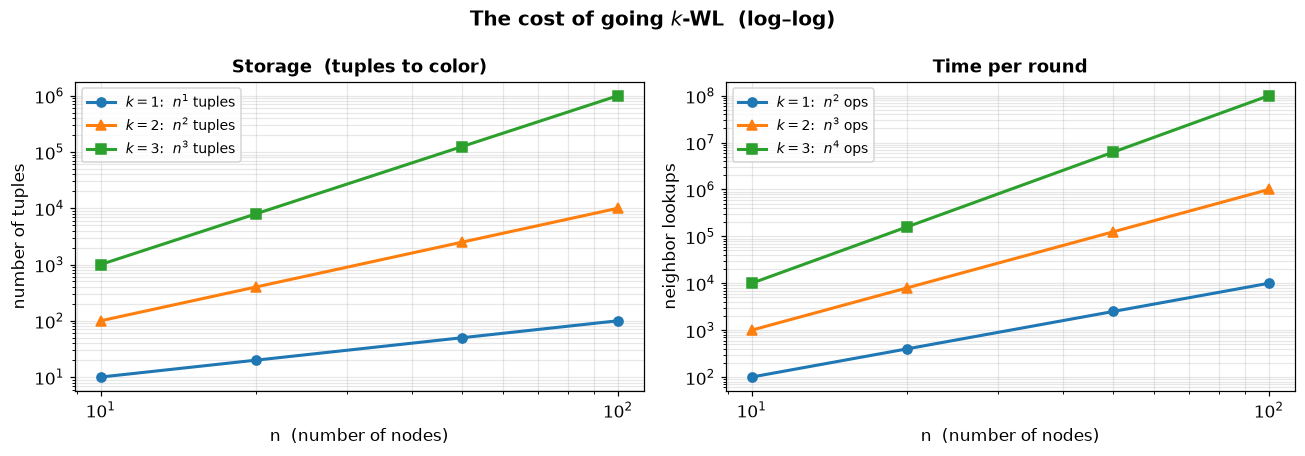

k    n         storage n^k     time n^(k+1)
1    20                 20              400
1    100               100           10,000
2    20                400            8,000
2    100            10,000        1,000,000
3    20              8,000          160,000
3    100         1,000,000      100,000,000


In [32]:
ns = np.array([10, 20, 50, 100])
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
for k, marker in zip([1, 2, 3], "o^s"):
    axes[0].plot(ns, ns ** k, marker=marker, lw=2, label=fr"$k={k}$:  $n^{k}$ tuples")
    axes[1].plot(ns, ns ** (k + 1), marker=marker, lw=2, label=fr"$k={k}$:  $n^{k+1}$ ops")
for ax, title, ylabel in zip(
    axes,
    ["Storage  (tuples to color)", "Time per round"],
    ["number of tuples", "neighbor lookups"],
):
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("n  (number of nodes)")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True, which="both", alpha=0.3)
    ax.legend(fontsize=9)
fig.suptitle("The cost of going $k$-WL  (log–log)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"{'k':<4} {'n':<6} {'storage n^k':>14} {'time n^(k+1)':>16}")
for k in (1, 2, 3):
    for n in (20, 100):
        print(f"{k:<4} {n:<6} {n**k:>14,} {n**(k+1):>16,}")


## 9. Graph Substructure Networks (GSN)

GSN adds subgraph-isomorphism counts (by automorphism orbit) as node or edge features. Message passing does not change.

- An automorphism of a motif $H$ is an isomorphism $H\to H$.
- Aut$(H)$ partitions $V(H)$ into orbits (the midpoint of $P_3$ vs the two ends).
- Feature of $v$: how many copies of $H$ place $v$ in a given orbit.

For $C_k$ there is one vertex orbit, so the feature is just how many $k$-cycles contain $v$.


In [33]:
def cycle_features(G, lengths=(3, 4, 5, 6)):
    """How many undirected k-cycles contain each vertex (GSN-v for H = C_k)."""
    feat = {v: {L: 0 for L in lengths} for v in G.nodes()}
    seen = set()
    for cyc in nx.simple_cycles(G.to_directed()):
        L = len(cyc)
        if L not in lengths:
            continue
        # NetworkX lists each directed cycle once (rotations identified).
        # Keep a rotation/reversal canonical key so we count each undirected cycle once.
        rot = tuple(cyc)
        fwd = min(rot[i:] + rot[:i] for i in range(L))
        rev = tuple(reversed(rot))
        bwd = min(rev[i:] + rev[:i] for i in range(L))
        key = min(fwd, bwd)
        if key in seen:
            continue
        seen.add(key)
        for v in cyc:
            feat[v][L] += 1
    return feat


def show_cycle_features(G, name, lengths=(3, 4, 5, 6)):
    feat = cycle_features(G, lengths)
    print(f"{name}:")
    for v in list(G.nodes())[: min(6, G.number_of_nodes())]:
        print(f"  node {v}: " + ", ".join(f"C{L}={feat[v][L]}" for L in lengths))
    sig = tuple(sorted(tuple(feat[v][L] for L in lengths) for v in G))
    print(f"  graph signature {sig}")
    return sig


print("GSN-v cycle counts (one orbit per C_k)")
print("(C3 recovers the usual triangle count; C6 vs 2xC3 differ on C3 and C6.)")
print()
sig_c6 = show_cycle_features(C6, "C6")
sig_2c3 = show_cycle_features(TwoC3, "2 x C3")
print(f"\nC6 vs 2xC3 signatures equal? {sig_c6 == sig_2c3}   (1-WL could not see this)")

print()
sig_dec = show_cycle_features(DEC, "decalin cartoon")
sig_bic = show_cycle_features(BIC, "bicyclopentyl cartoon")
print(f"\ndecalin vs bicyclopentyl signatures equal? {sig_dec == sig_bic}")
print("GSN features plug into any MPNN as extra node channels: message passing is untouched.")


GSN-v cycle counts (one orbit per C_k)
(C3 recovers the usual triangle count; C6 vs 2xC3 differ on C3 and C6.)

C6:
  node 0: C3=0, C4=0, C5=0, C6=1
  node 1: C3=0, C4=0, C5=0, C6=1
  node 2: C3=0, C4=0, C5=0, C6=1
  node 3: C3=0, C4=0, C5=0, C6=1
  node 4: C3=0, C4=0, C5=0, C6=1
  node 5: C3=0, C4=0, C5=0, C6=1
  graph signature ((0, 0, 0, 1), (0, 0, 0, 1), (0, 0, 0, 1), (0, 0, 0, 1), (0, 0, 0, 1), (0, 0, 0, 1))
2 x C3:
  node 0: C3=1, C4=0, C5=0, C6=0
  node 1: C3=1, C4=0, C5=0, C6=0
  node 2: C3=1, C4=0, C5=0, C6=0
  node 3: C3=1, C4=0, C5=0, C6=0
  node 4: C3=1, C4=0, C5=0, C6=0
  node 5: C3=1, C4=0, C5=0, C6=0
  graph signature ((1, 0, 0, 0), (1, 0, 0, 0), (1, 0, 0, 0), (1, 0, 0, 0), (1, 0, 0, 0), (1, 0, 0, 0))

C6 vs 2xC3 signatures equal? False   (1-WL could not see this)

decalin cartoon:
  node 0: C3=0, C4=0, C5=0, C6=1
  node 1: C3=0, C4=0, C5=0, C6=1
  node 2: C3=0, C4=0, C5=0, C6=1
  node 3: C3=0, C4=0, C5=0, C6=1
  node 4: C3=0, C4=0, C5=0, C6=2
  node 5: C3=0, C4=0, C5=0,

## 10. From stars to subgraphs (GNN-AK)

A star MPNN sees the neighbors of $v$, not the edges among those neighbors. That is why a triangle and a 3-path look the same from the root after one hop.

GNN-AK (Zhao et al., ICLR 2022) replaces the star with the $k$-hop induced egonet and runs a GNN inside that subgraph.

At $k=1$, the 1-hop egonet of a node in $C_6$ is a path $P_3$ (neighbors are not adjacent). In $2\times C_3$ it is a triangle (they are). The star cannot see that extra edge; the egonet can.


C6 node 0, 1-hop egonet:  n=3  m=2  edges among neighbors=0  triangles=0  WL-hash=68a20d134ccf997b149622d5476cb4cb
2 x C3 node 0, 1-hop egonet:  n=3  m=3  edges among neighbors=1  triangles=1  WL-hash=d41316288e6b8bab957f3b304df0b032
egonet hashes equal? False


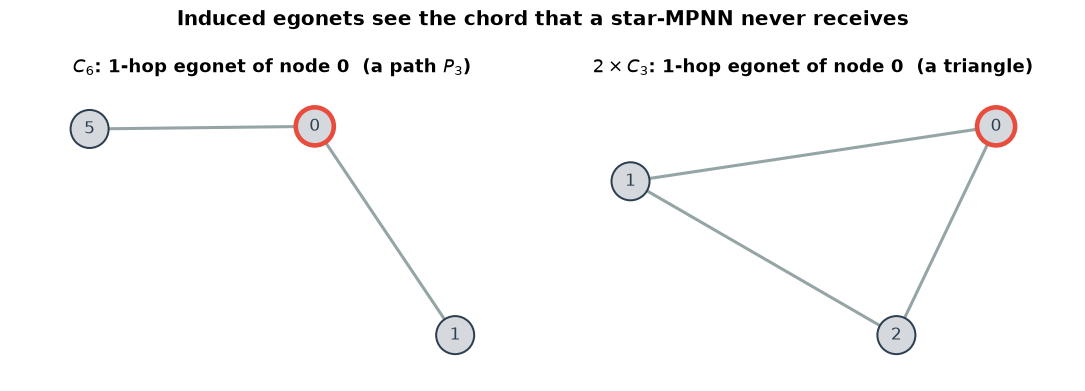

In [34]:
def k_egonet(G, v, k=1):
    dist = nx.single_source_shortest_path_length(G, v, cutoff=k)
    return G.subgraph(list(dist)).copy()


def describe_egonet(G, name, v=0, k=1):
    H = k_egonet(G, v, k=k)
    n_edges_among_nbrs = H.number_of_edges() - G.degree(v)   # edges not incident to the root
    print(f"{name} node {v}, {k}-hop egonet:  "
          f"n={H.number_of_nodes()}  m={H.number_of_edges()}  "
          f"edges among neighbors={n_edges_among_nbrs}  "
          f"triangles={sum(nx.triangles(H).values()) // 3}  "
          f"WL-hash={nx.weisfeiler_lehman_graph_hash(H, iterations=3)}")
    return H


H_c6 = describe_egonet(C6, "C6")
H_2c3 = describe_egonet(TwoC3, "2 x C3")
print(f"egonet hashes equal? {nx.weisfeiler_lehman_graph_hash(H_c6) == nx.weisfeiler_lehman_graph_hash(H_2c3)}")

fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
draw_graph(H_c6, nx.spring_layout(H_c6, seed=0), axes[0], highlight=0,
           title="$C_6$: 1-hop egonet of node 0  (a path $P_3$)")
draw_graph(H_2c3, nx.spring_layout(H_2c3, seed=1), axes[1], highlight=0,
           title=r"$2\times C_3$: 1-hop egonet of node 0  (a triangle)")
fig.suptitle("Induced egonets see the chord that a star-MPNN never receives",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


## 11. Equivariant subgraph aggregation (ESAN)

ESAN (Bevilacqua et al.) maps $G$ to a bag of subgraphs, encodes each one, then pools. Typical policies: delete a node, delete an edge, or take $k$-hop egonets.

$$
1\text{-WL} \;<\; \text{DS-WL} \;\subseteq\; \text{DSS-WL}.
$$

Node deletion already splits $C_6$ vs $2\times C_3$: $C_6-v$ is always $P_5$, and $(2\times C_3)-v$ is always $C_3\sqcup P_2$. Those two subgraphs are 1-WL-separable, so the bags are too.


Node-deletion policy  (one subgraph per vertex)
  C6 bag hashes:     ('29e26218b9662ab1f09f534283c863cf', '29e26218b9662ab1f09f534283c863cf', '29e26218b9662ab1f09f534283c863cf', '29e26218b9662ab1f09f534283c863cf', '29e26218b9662ab1f09f534283c863cf', '29e26218b9662ab1f09f534283c863cf')
  2xC3 bag hashes:   ('c271adac5fb798de67e0dfc342655371', 'c271adac5fb798de67e0dfc342655371', 'c271adac5fb798de67e0dfc342655371', 'c271adac5fb798de67e0dfc342655371', 'c271adac5fb798de67e0dfc342655371', 'c271adac5fb798de67e0dfc342655371')
  bags equal? False

1-WL on a representative node-deleted subgraph:
round 0:  C6 - v   {1: 5}                             ==  (2xC3) - v {1: 5}
round 1:  C6 - v   {2: 2, 3: 3}                       ==  (2xC3) - v {2: 2, 3: 3}
round 2:  C6 - v   {4: 2, 5: 2, 6: 1}                 !=  (2xC3) - v {6: 3, 7: 2}
round 3:  C6 - v   {8: 2, 9: 2, 10: 1}                !=  (2xC3) - v {11: 2, 12: 3}

→ NON-ISOMORPHIC (the histograms differ)


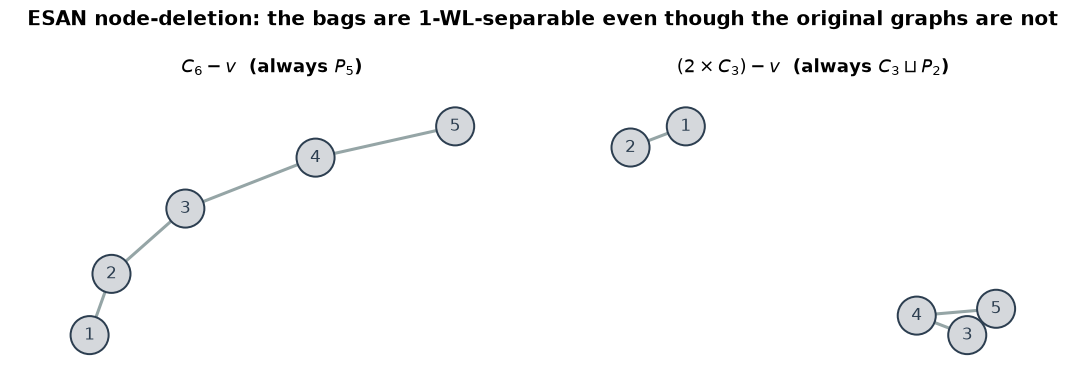

In [35]:
def node_deleted_bag(G):
    return [G.subgraph([u for u in G if u != v]).copy() for v in G]


def bag_signature(bag, iterations=3):
    """Multiset of 1-WL hashes of the subgraphs in the bag."""
    return tuple(sorted(nx.weisfeiler_lehman_graph_hash(H, iterations=iterations) for H in bag))


bag_c6 = node_deleted_bag(C6)
bag_2c3 = node_deleted_bag(TwoC3)

print("Node-deletion policy  (one subgraph per vertex)")
print(f"  C6 bag hashes:     {bag_signature(bag_c6)}")
print(f"  2xC3 bag hashes:   {bag_signature(bag_2c3)}")
print(f"  bags equal? {bag_signature(bag_c6) == bag_signature(bag_2c3)}")

# 1-WL on a representative deleted subgraph
P5 = bag_c6[0]
C3P2 = bag_2c3[0]
print("\n1-WL on a representative node-deleted subgraph:")
wl_report(wl_refine([P5, C3P2], num_iterations=3), ["C6 - v  ", "(2xC3) - v"])

fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
draw_graph(P5, nx.spring_layout(P5, seed=0), axes[0], title="$C_6 - v$  (always $P_5$)")
draw_graph(C3P2, nx.spring_layout(C3P2, seed=1), axes[1],
           title=r"$(2\times C_3) - v$  (always $C_3 \sqcup P_2$)")
fig.suptitle("ESAN node-deletion: the bags are 1-WL-separable even though the original graphs are not",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()
